# 04: PCA Matemática Ilustrada

Este notebook demonstra passo-a-passo a matemática do PCA com ilustrações.

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

In [26]:
# Configuração global
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False

## 1. Dados Simulados 2D

In [27]:
# Gerar dados 2D com correlação (para visualização clara)
np.random.seed(42)

# Média e matriz de covariância
mean = [2, 3]
cov = [[1.5, 1.0], [1.0, 1.0]]  # correlação positiva

X_original = np.random.multivariate_normal(mean, cov, 100)

print("Dados originais shape:", X_original.shape)
print("Média:", X_original.mean(axis=0))

Dados originais shape: (100, 2)
Média: [2.12776051 3.11996248]


## 2. Centralização (subtrair média)

In [28]:
# Centralizar dados
X_centered = X_original - X_original.mean(axis=0)

print("Média após centralização:", X_centered.mean(axis=0))
print("(deve ser aproximadamente [0, 0])")

Média após centralização: [-6.83897383e-16 -1.31228362e-15]
(deve ser aproximadamente [0, 0])


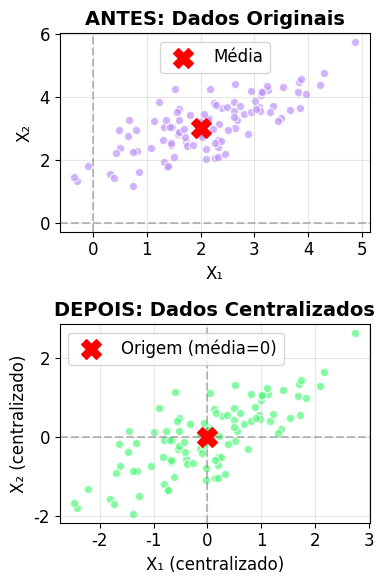

Gráfico salvo: ../graficos/covariancia_centralizacao.png


In [39]:
# Visualização ANTES / DEPOIS da centralização
fig, axes = plt.subplots(2, 1, figsize=(4, 6))

# ANTES
axes[0].scatter(X_original[:, 0], X_original[:, 1], alpha=0.7, c='#bd93f9', edgecolors='white')
axes[0].scatter(mean[0], mean[1], c='red', s=200, marker='X', label='Média', zorder=5)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('X₁')
axes[0].set_ylabel('X₂')
axes[0].set_title('ANTES: Dados Originais', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# DEPOIS
axes[1].scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.7, c='#50fa7b', edgecolors='white')
axes[1].scatter(0, 0, c='red', s=200, marker='X', label='Origem (média=0)', zorder=5)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('X₁ (centralizado)')
axes[1].set_ylabel('X₂ (centralizado)')
axes[1].set_title('DEPOIS: Dados Centralizados', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../graficos/covariancia_centralizacao.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo: ../graficos/covariancia_centralizacao.png")

## 3. Matriz de Covariância

In [30]:
# Cálculo da matriz de covariância
# Cov(X) = E[(X - μ)(X - μ)ᵀ]
# Para dados centralizados: Cov = (1/(n-1)) * XᵀX

n = X_centered.shape[0]
cov_matrix = (X_centered.T @ X_centered) / (n - 1)

print("Matriz de Covariância:")
print(f"[[{cov_matrix[0,0]:.4f}, {cov_matrix[0,1]:.4f}]")
print(f" [{cov_matrix[1,0]:.4f}, {cov_matrix[1,1]:.4f}]]")

# Usando numpy (verificação)
cov_numpy = np.cov(X_centered.T)
print("\nVerificação com np.cov():")
print(cov_numpy)

Matriz de Covariância:
[[1.1408, 0.7004]
 [0.7004, 0.7503]]

Verificação com np.cov():
[[1.14082979 0.70041008]
 [0.70041008 0.75032382]]


## 4. Autovetores e Autovalores

In [31]:
# Autovetores e autovalores
# Av = λv  →  (A - λI)v = 0

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Ordenar por autovalor (maior primeiro)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("Autovalores (λ):", eigenvalues)
print("\nAutovetores (v):")
for i, (val, vec) in enumerate(zip(eigenvalues, eigenvectors.T)):
    print(f"  PC{i+1}: λ={val:.4f}, v=[{vec[0]:.4f}, {vec[1]:.4f}]")

Autovalores (λ): [1.67269303 0.21846058]

Autovetores (v):
  PC1: λ=1.6727, v=[0.7964, 0.6048]
  PC2: λ=0.2185, v=[-0.6048, 0.7964]


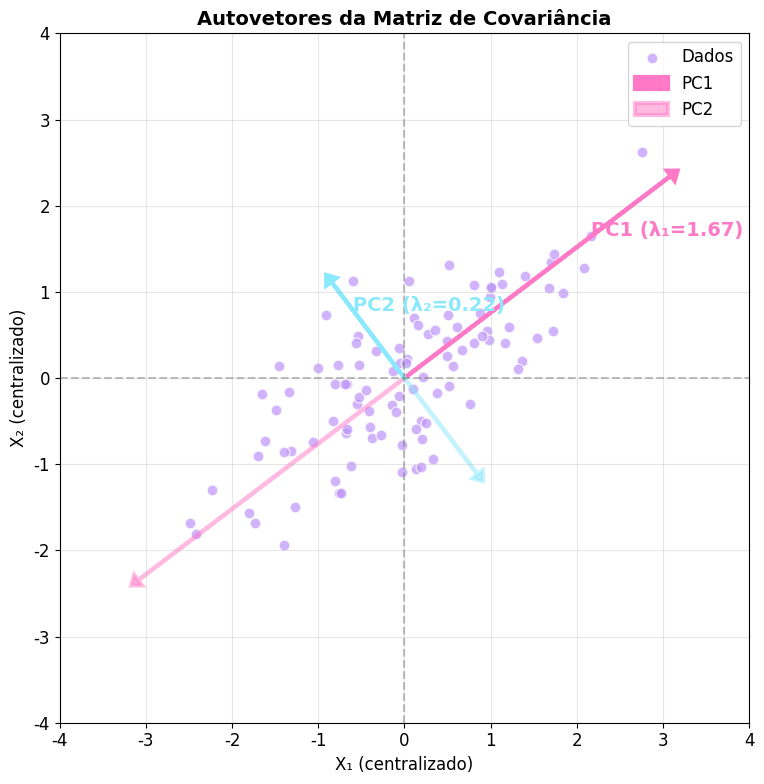

Gráfico salvo: ../graficos/autovetores_matriz.png


In [32]:
# Visualizar autovetores sobre o scatter plot
fig, ax = plt.subplots(figsize=(10, 8))

# Dados centralizados
ax.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.7, c='#bd93f9', 
           edgecolors='white', s=60, label='Dados')

# Autovetores escalados por raiz quadrada do autovalor
scale1 = np.sqrt(eigenvalues[0]) * 3
scale2 = np.sqrt(eigenvalues[1]) * 3

# PC1 (maior autovalor)
ax.arrow(0, 0, eigenvectors[0, 0] * scale1, eigenvectors[1, 0] * scale1,
         head_width=0.15, head_length=0.1, fc='#ff79c6', ec='#ff79c6', linewidth=3)
ax.arrow(0, 0, -eigenvectors[0, 0] * scale1, -eigenvectors[1, 0] * scale1,
         head_width=0.15, head_length=0.1, fc='#ff79c6', ec='#ff79c6', linewidth=3, alpha=0.5)

# PC2 (segundo maior)
ax.arrow(0, 0, eigenvectors[0, 1] * scale2, eigenvectors[1, 1] * scale2,
         head_width=0.15, head_length=0.1, fc='#8be9fd', ec='#8be9fd', linewidth=3)
ax.arrow(0, 0, -eigenvectors[0, 1] * scale2, -eigenvectors[1, 1] * scale2,
         head_width=0.15, head_length=0.1, fc='#8be9fd', ec='#8be9fd', linewidth=3, alpha=0.5)

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

# Legenda
ax.annotate(f'PC1 (λ₁={eigenvalues[0]:.2f})', 
            xy=(eigenvectors[0, 0] * scale1 * 0.7, eigenvectors[1, 0] * scale1 * 0.7),
            fontsize=14, color='#ff79c6', fontweight='bold')
ax.annotate(f'PC2 (λ₂={eigenvalues[1]:.2f})', 
            xy=(eigenvectors[0, 1] * scale2 * 0.7, eigenvectors[1, 1] * scale2 * 0.7),
            fontsize=14, color='#8be9fd', fontweight='bold')

ax.set_xlabel('X₁ (centralizado)', fontsize=12)
ax.set_ylabel('X₂ (centralizado)', fontsize=12)
ax.set_title('Autovetores da Matriz de Covariância', fontsize=14, fontweight='bold')
ax.legend(['Dados', 'PC1', 'PC2'])
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)

plt.tight_layout()
plt.savefig('../graficos/autovetores_matriz.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo: ../graficos/autovetores_matriz.png")

## 5. Decomposição Espectral: Cov = QΛQᵀ

In [33]:
# Decomposição Espectral
# Cov = Q Λ Qᵀ
# Q = matriz de autovetores (ortogonal)
# Λ = matriz diagonal de autovalores

Q = eigenvectors  # cada coluna é um autovetor
Lambda = np.diag(eigenvalues)  # matriz diagonal

print("Q (autovetores):")
print(Q)

print("\nΛ (autovalores na diagonal):")
print(Lambda)

# Verificação: Q Λ Qᵀ = Cov
reconstructed = Q @ Lambda @ Q.T
print("\nVerificação: Q Λ Qᵀ =")
print(reconstructed)

print("\nCov original:")
print(cov_matrix)

print("\nDiferença (deve ser ~0):", np.max(np.abs(reconstructed - cov_matrix)))

Q (autovetores):
[[ 0.79640776 -0.60476002]
 [ 0.60476002  0.79640776]]

Λ (autovalores na diagonal):
[[1.67269303 0.        ]
 [0.         0.21846058]]

Verificação: Q Λ Qᵀ =
[[1.14082979 0.70041008]
 [0.70041008 0.75032382]]

Cov original:
[[1.14082979 0.70041008]
 [0.70041008 0.75032382]]

Diferença (deve ser ~0): 2.220446049250313e-16


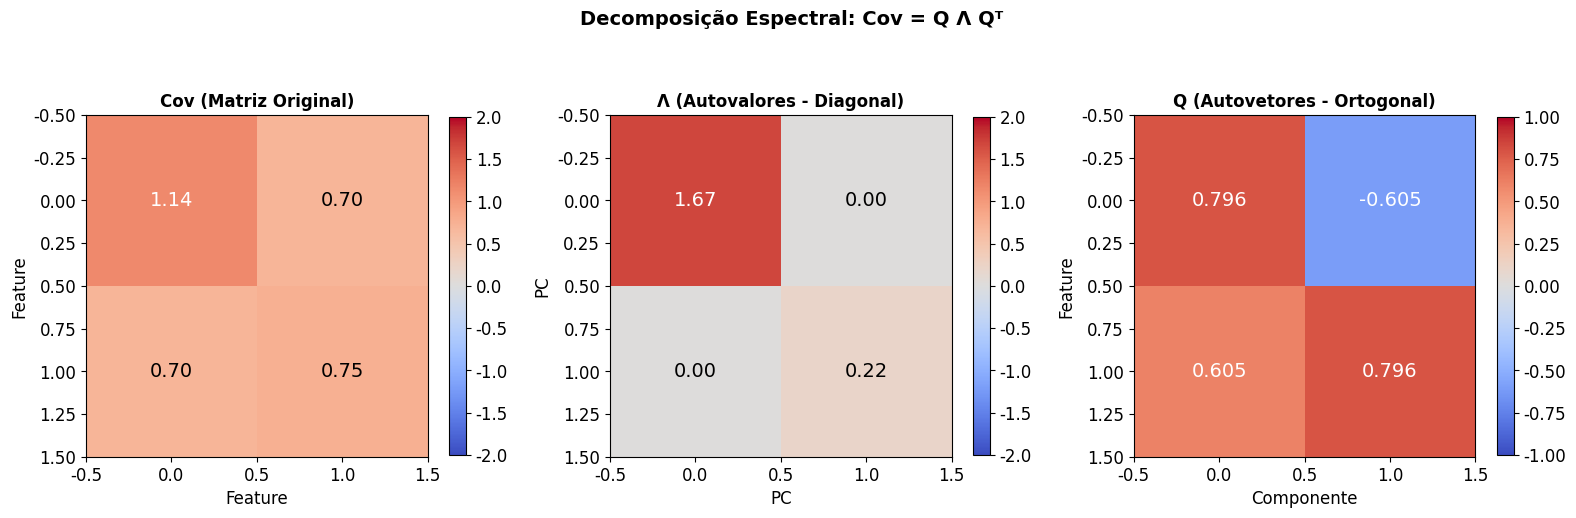

Gráfico salvo: ../graficos/decomposicao_espectral.png


In [34]:
# Visualização da decomposição espectral
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Cov
im1 = axes[0].imshow(cov_matrix, cmap='coolwarm', vmin=-2, vmax=2)
axes[0].set_title('Cov (Matriz Original)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Feature')
axes[0].set_ylabel('Feature')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f'{cov_matrix[i,j]:.2f}', ha='center', va='center', 
                   color='white' if abs(cov_matrix[i,j]) > 1 else 'black', fontsize=14)
plt.colorbar(im1, ax=axes[0], shrink=0.8)

# Λ (autovalores)
im2 = axes[1].imshow(Lambda, cmap='coolwarm', vmin=-2, vmax=2)
axes[1].set_title('Λ (Autovalores - Diagonal)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PC')
axes[1].set_ylabel('PC')
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, f'{Lambda[i,j]:.2f}', ha='center', va='center', 
                   color='white' if abs(Lambda[i,j]) > 1 else 'black', fontsize=14)
plt.colorbar(im2, ax=axes[1], shrink=0.8)

# Q (autovetores)
im3 = axes[2].imshow(Q, cmap='coolwarm', vmin=-1, vmax=1)
axes[2].set_title('Q (Autovetores - Ortogonal)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Componente')
axes[2].set_ylabel('Feature')
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, f'{Q[i,j]:.3f}', ha='center', va='center', 
                   color='white' if abs(Q[i,j]) > 0.5 else 'black', fontsize=14)
plt.colorbar(im3, ax=axes[2], shrink=0.8)

plt.suptitle('Decomposição Espectral: Cov = Q Λ Qᵀ', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../graficos/decomposicao_espectral.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo: ../graficos/decomposicao_espectral.png")

## 6. Exemplo Numérico 2x2 Completo

In [35]:
# Exemplo numérico simples 2x2
# Dados: X = [[2, 1], [4, 3], [6, 5]]

X_manual = np.array([[2, 1],
                    [4, 3],
                    [6, 5]])

print("Dados originais X:")
print(X_manual)

# Passo 1: Centralizar
mean_manual = X_manual.mean(axis=0)
X_centered_manual = X_manual - mean_manual

print("\n1. Centralizar (X - média):")
print("Média:", mean_manual)
print("X centralizado:")
print(X_centered_manual)

# Passo 2: Matriz de Covariância
# Para n=3, divisor é (n-1)=2
cov_manual = X_centered_manual.T @ X_centered_manual / 2

print("\n2. Matriz de Covariância (Xcᵀ Xc / (n-1)):")
print(cov_manual)

# Passo 3: Autovetores e Autovalores
eigenvalues_manual, eigenvectors_manual = np.linalg.eig(cov_manual)

print("\n3. Autovalores e Autovetores:")
print("Autovalores:", eigenvalues_manual)
print("Autovetores (colunas):")
print(eigenvectors_manual)

# Passo 4: Ordenar
idx = np.argsort(eigenvalues_manual)[::-1]
eigenvalues_sorted = eigenvalues_manual[idx]
eigenvectors_sorted = eigenvectors_manual[:, idx]

print("\n4. Ordenados por importância:")
print("PC1 (maior): λ =", eigenvalues_sorted[0].real, ", v =", eigenvectors_sorted[:, 0].real)
print("PC2: λ =", eigenvalues_sorted[1].real, ", v =", eigenvectors_sorted[:, 1].real)

Dados originais X:
[[2 1]
 [4 3]
 [6 5]]

1. Centralizar (X - média):
Média: [4. 3.]
X centralizado:
[[-2. -2.]
 [ 0.  0.]
 [ 2.  2.]]

2. Matriz de Covariância (Xcᵀ Xc / (n-1)):
[[4. 4.]
 [4. 4.]]

3. Autovalores e Autovetores:
Autovalores: [8. 0.]
Autovetores (colunas):
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

4. Ordenados por importância:
PC1 (maior): λ = 8.0 , v = [0.70710678 0.70710678]
PC2: λ = 0.0 , v = [-0.70710678  0.70710678]


## 7. Variância Explicada e Cumulativa

Variância por componente:
  PC1: λ = 1.6727 → 88.45% da variância total
  PC2: λ = 0.2185 → 11.55% da variância total

Total: 1.8912


/tmp/ipykernel_1851318/1626988447.py:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  axes[1].plot(range(1, len(eigenvalues)+1), cumulative_variance * 100, 'bo-',


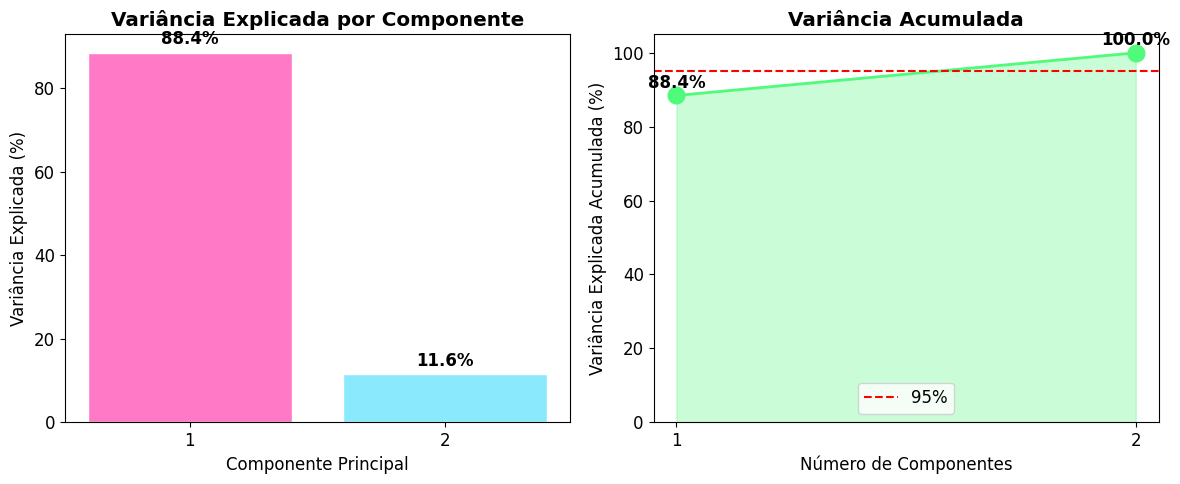

Gráfico salvo: ../graficos/variancia_explicada_cumulativa.png


In [36]:
# Variância explicada
total_variance = np.sum(eigenvalues)
variance_ratio = eigenvalues / total_variance
cumulative_variance = np.cumsum(variance_ratio)

print("Variância por componente:")
for i, (val, ratio) in enumerate(zip(eigenvalues, variance_ratio)):
    print(f"  PC{i+1}: λ = {val:.4f} → {ratio*100:.2f}% da variância total")

print(f"\nTotal: {total_variance:.4f}")

# Gráfico de cotovelo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barras
axes[0].bar(range(1, len(eigenvalues)+1), variance_ratio * 100, 
            color=['#ff79c6', '#8be9fd'], edgecolor='white')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Variância Explicada (%)')
axes[0].set_title('Variância Explicada por Componente', fontweight='bold')
axes[0].set_xticks([1, 2])
for i, v in enumerate(variance_ratio):
    axes[0].text(i+1, v*100 + 2, f'{v*100:.1f}%', ha='center', fontsize=12, fontweight='bold')

# Cumulativa
axes[1].plot(range(1, len(eigenvalues)+1), cumulative_variance * 100, 'bo-', 
            markersize=12, linewidth=2, color='#50fa7b')
axes[1].fill_between(range(1, len(eigenvalues)+1), 0, cumulative_variance * 100, 
                     alpha=0.3, color='#50fa7b')
axes[1].axhline(y=95, color='red', linestyle='--', label='95%')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Variância Explicada Acumulada (%)')
axes[1].set_title('Variância Acumulada', fontweight='bold')
axes[1].legend()
axes[1].set_xticks([1, 2])
axes[1].set_ylim(0, 105)
for i, v in enumerate(cumulative_variance):
    axes[1].text(i+1, v*100 + 2, f'{v*100:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../graficos/variancia_explicada_cumulativa.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo: ../graficos/variancia_explicada_cumulativa.png")